## Aim: 

Appraise areas of BCFZ using NDVI (Normalised Difference Vegetation Index) and derivatives (i.e. Laplace, variance).

In [82]:
import matplotlib.pyplot as plt
import rasterio as rio
import numpy as np
from pathlib import Path
import glob

In [83]:
paths = glob.glob('../../../data/NDVI/*/composite.tif')

In [85]:
NDVItiles = []
NDWItiles = []

for p in paths:
    with rio.open(p) as src:
        b = src.read(1).astype(np.float32) / 10000.0
        g = src.read(2).astype(np.float32) / 10000.0
        r = src.read(3).astype(np.float32) / 10000.0
        nir = src.read(4).astype(np.float32) / 10000.0

        # NDVI 
        denom = nir + r

        ndvi = np.full_like(denom, np.nan, dtype=np.float32)
        mask = denom > 0

        ndvi[mask] = (nir[mask] - r[mask]) / denom[mask]

        # NDWI

        denom = nir + g

        ndwi = np.full_like(denom, np.nan, dtype=np.float32)
        mask = denom > 0

        ndwi[mask] = (nir[mask] - g[mask]) / denom[mask]


        NDVItiles.append(ndvi)
        NDWItiles.append(ndwi)

NDWItiles = np.stack(NDWItiles, axis=0)
NDVItiles = np.stack(NDVItiles, axis=0)

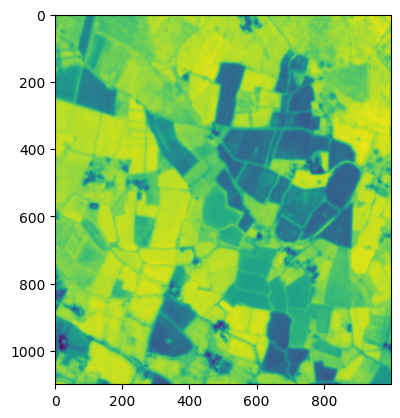

In [92]:
AOI = NDWItiles[:, 5400:6500, 4750:5750]
plt.imshow(AOI[0])

In [93]:
var = np.var(AOI, axis=0)

from scipy.ndimage import uniform_filter

neighbourhood_mean = uniform_filter(var, size=10, mode='nearest')

lvvi = var - neighbourhood_mean

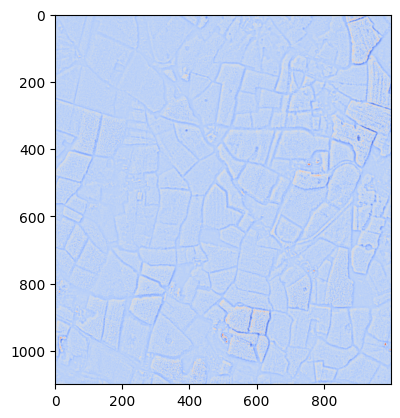

In [94]:
plt.imshow(lvvi, cmap='coolwarm')

In [95]:
AOI2 = NDWItiles[:, 8000:8500, 3750:4250]

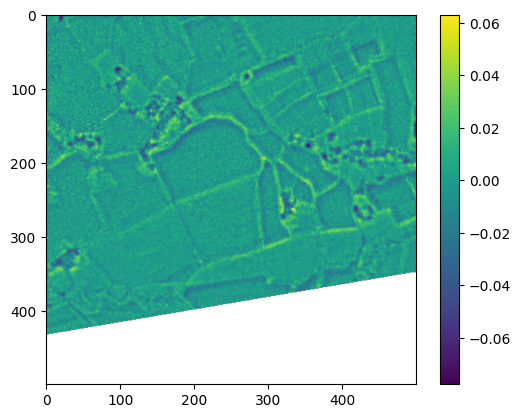

In [96]:
mean = np.mean(AOI2, axis=0)

from scipy.ndimage import uniform_filter

neighbourhood_mean = uniform_filter(mean, size=10, mode='nearest')

lvi = mean - neighbourhood_mean
plt.imshow(lvi, cmap='viridis')
plt.colorbar()